In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = sns.load_dataset('titanic')

print(df.head())
print(df.info())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64

In [3]:
mean_age = df["age"].mean()
median_age = df["age"].median()
var_age = df["age"].var()
std_age = df["age"].std() 

print(f"Age-Mean : {mean_age:.2f}, Age-Median : {median_age:.2f}")
print(f"Age-Variance : {var_age:.2f} , Age-Standard Deviation : {std_age:.2f}")

Age-Mean : 29.70, Age-Median : 28.00
Age-Variance : 211.02 , Age-Standard Deviation : 14.53


<function matplotlib.pyplot.show(close=None, block=None)>

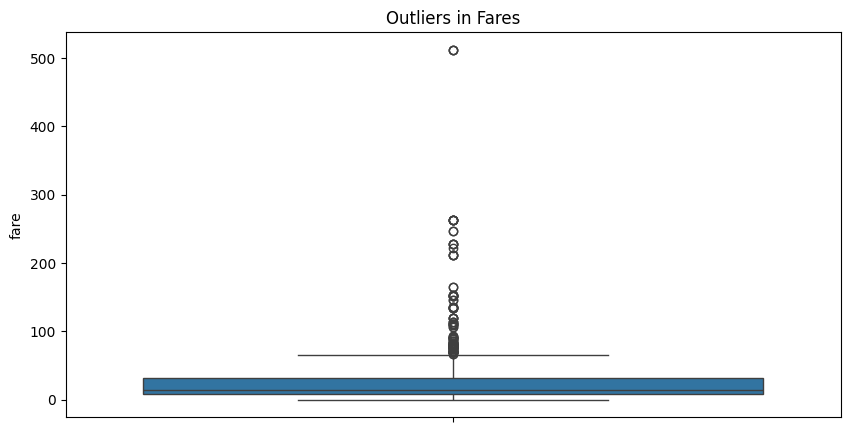

In [4]:
plt.figure(figsize=(10,5))
sns.boxplot(df["fare"])
plt.title("Outliers in Fares")
plt.show

In [5]:
Q1 = df['fare'].quantile(0.25)
Q2=df['fare'].quantile(0.5)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

print(f"Fares Q1:{Q1}, Q2:{Q2}, Q3:{Q3}")
print(f"Any Fare above{upper_whisker} is and outlier")

outlier = df[df["fare"] > upper_whisker]
print(f"Number of outlier : {len(outlier)}")

Fares Q1:7.9104, Q2:14.4542, Q3:31.0
Any Fare above65.6344 is and outlier
Number of outlier : 116


In [6]:
df['age']= df["age"].fillna(median_age)
df['sex']= df["sex"].map({'male': 0, 'female' : 1  })

print(df[["age","sex"]].isnull().sum())
print(df[["age", "sex"]].head())

age    0
sex    0
dtype: int64
    age  sex
0  22.0    0
1  38.0    1
2  26.0    1
3  35.0    1
4  35.0    0


In [7]:

df.info(14)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(5), str(4)
memory usage: 80.7 KB


In [8]:
scalar = StandardScaler()

df["scaled_fare"] = scalar.fit_transform(df[['fare']])

print(df[['fare', 'scaled_fare']].head())

      fare  scaled_fare
0   7.2500    -0.502445
1  71.2833     0.786845
2   7.9250    -0.488854
3  53.1000     0.420730
4   8.0500    -0.486337


In [9]:
df[["age","fare"]] = scalar.fit_transform(df[['age','fare']])

print("Scaled Data (First 5 rows):")
print(df[['age', 'fare']].head())

Scaled Data (First 5 rows):
        age      fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


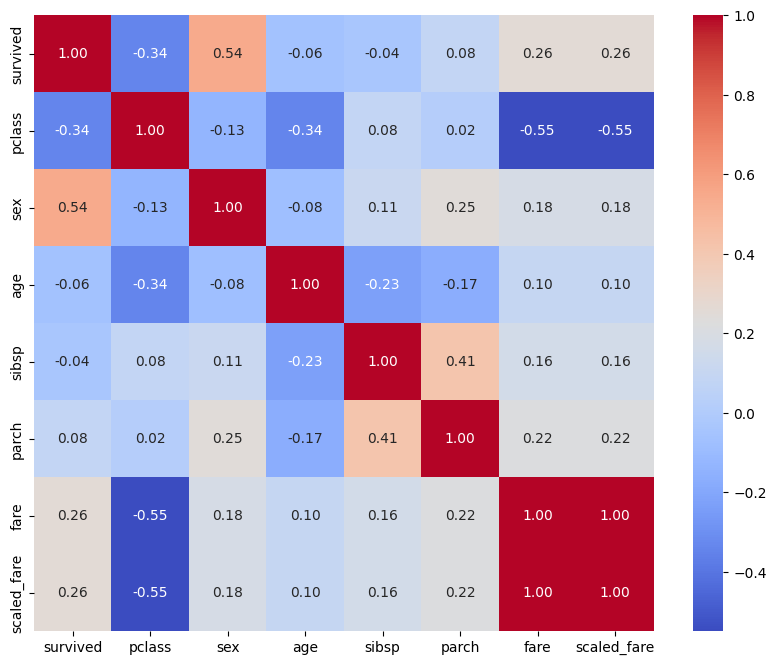

             survived    pclass       sex       age     sibsp     parch  \
survived     1.000000 -0.338481  0.543351 -0.064910 -0.035322  0.081629   
pclass      -0.338481  1.000000 -0.131900 -0.339898  0.083081  0.018443   
sex          0.543351 -0.131900  1.000000 -0.081163  0.114631  0.245489   
age         -0.064910 -0.339898 -0.081163  1.000000 -0.233296 -0.172482   
sibsp       -0.035322  0.083081  0.114631 -0.233296  1.000000  0.414838   
parch        0.081629  0.018443  0.245489 -0.172482  0.414838  1.000000   
fare         0.257307 -0.549500  0.182333  0.096688  0.159651  0.216225   
scaled_fare  0.257307 -0.549500  0.182333  0.096688  0.159651  0.216225   

                 fare  scaled_fare  
survived     0.257307     0.257307  
pclass      -0.549500    -0.549500  
sex          0.182333     0.182333  
age          0.096688     0.096688  
sibsp        0.159651     0.159651  
parch        0.216225     0.216225  
fare         1.000000     1.000000  
scaled_fare  1.000000     1.

In [10]:
cormat = df.select_dtypes(include=["number"]).corr()
plt.figure(figsize = (10,8))
sns.heatmap(cormat, annot=True, cmap ='coolwarm', fmt = '.2f')
plt.show()
print(cormat)